<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/01_Colab_LLM%E1%84%8F%E1%85%A9%E1%84%83%E1%85%B5%E1%86%BC_%E1%84%8B%E1%85%AF%E1%84%86%E1%85%B5%E1%86%BC%E1%84%8B%E1%85%A5%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 01 · Colab & LLM 코딩 워밍업
### 제약바이오 AI 기초

**이 노트북에서 배우는 것**
- Google Colab 사용법
- 코드 셀 실행, 라이브러리 설치, 파일 업로드
- pandas 로 데이터 열어보기
- **LLM(Gemini/Claude)를 이용한 코딩**

> **"문제 정의 → LLM에게 코드를 요청 → Colab에서 실행·검증"** 하는
> 실무 워크플로우를 몸에 익히는 것이 목표입니다.


## 1. Colab 이란?
- 브라우저만 있으면 되는 **무료 파이썬 실행 환경** (구글 계정 필요)
- 내 노트북 성능과 무관하게 구글 서버에서 실행됨 → **무료 GPU/TPU** 사용 가능
- 라이브러리가 대부분 미리 깔려 있고, 없으면 `!pip install` 한 줄로 설치

**셀 실행 방법**: 셀을 클릭 후 `Shift + Enter`  (또는 왼쪽 ▶ 버튼)


In [ ]:
# [실행해보기] 셀을 클릭하고 Shift+Enter 를 눌러보세요.
print("안녕하세요, 제약바이오 AI 과정에 오신 것을 환영합니다!")
1 + 2 * 3   # 마지막 줄의 결과는 자동으로 출력됩니다
# #이 앞에 붙으면 실행 안됨
# .이 뒤에 붙으면 그 항목의 하위목록임
# .뒤에 나오는 스팬는 변수, 정뮥면체는 함수임 df. 하고 좀 기다려보셈.

안녕하세요, 제약바이오 AI 과정에 오신 것을 환영합니다!


7

In [ ]:
# 지금 이 Colab 에 어떤 하드웨어가 붙어있는지 확인
import sys, platform
print("파이썬 버전 :", sys.version.split()[0])
print("운영체제    :", platform.platform())

# GPU 가 붙어있는지 확인 (상단 메뉴 [런타임]>[런타임 유형 변경]에서 GPU 선택 가능)
!nvidia-smi -L 2>/dev/null || echo "현재 GPU 미할당 (CPU 런타임)"

파이썬 버전 : 3.12.13
운영체제    : Linux-6.6.122+-x86_64-with-glibc2.35
현재 GPU 미할당 (CPU 런타임)


## 2. 라이브러리 설치와 불러오기
파이썬이 제공하는 기본 **도구상자(라이브러리)**
- `pandas` : 엑셀 같은 표(데이터프레임) 다루기
- `numpy`  : 숫자 계산
- `matplotlib` : 그래프

이미 설치돼 있으므로 `import` 만 하면 됩니다. (없다면 `!pip install 이름`)


In [ ]:
import pandas as pd          # 표 데이터
import numpy as np             # 숫자 계산
import matplotlib.pyplot as plt  # 그래프
print("라이브러리 준비 완료 ✅")

라이브러리 준비 완료 ✅


## 3. 제약 데이터 처음 열어보기
실제 신약개발에서 가장 유명한 공개 데이터 중 하나인 **용해도(solubility) 데이터**를
인터넷에서 바로 불러오겠습니다. (엑셀을 여는 것과 똑같습니다)

- 각 행 = 하나의 화합물(분자)
- `smiles` : 분자를 글자로 표현한 것 (예: 아스피린 = `CC(=O)Oc1ccccc1C(=O)O`)
- `measured log solubility ...` : 실제로 측정한 용해도 값 (신약이 되려면 물에 잘 녹아야 함)


In [ ]:
# 인터넷 CSV 파일을 pandas 로 바로 읽기 (Delaney/ESOL 용해도 데이터, 1128개 분자)
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print("데이터 크기 (행, 열):", df.shape)
df.head()   # 앞 5줄 미리보기

데이터 크기 (행, 열): (1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [ ]:
# 어떤 열(항목)들이 있는지, 숫자 열의 요약 통계
print("== 열 목록 ==")
print(list(df.columns), "\n")
df.describe()   # 평균/최소/최대 등 자동 요약

== 열 목록 ==
['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles'] 



,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,365 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


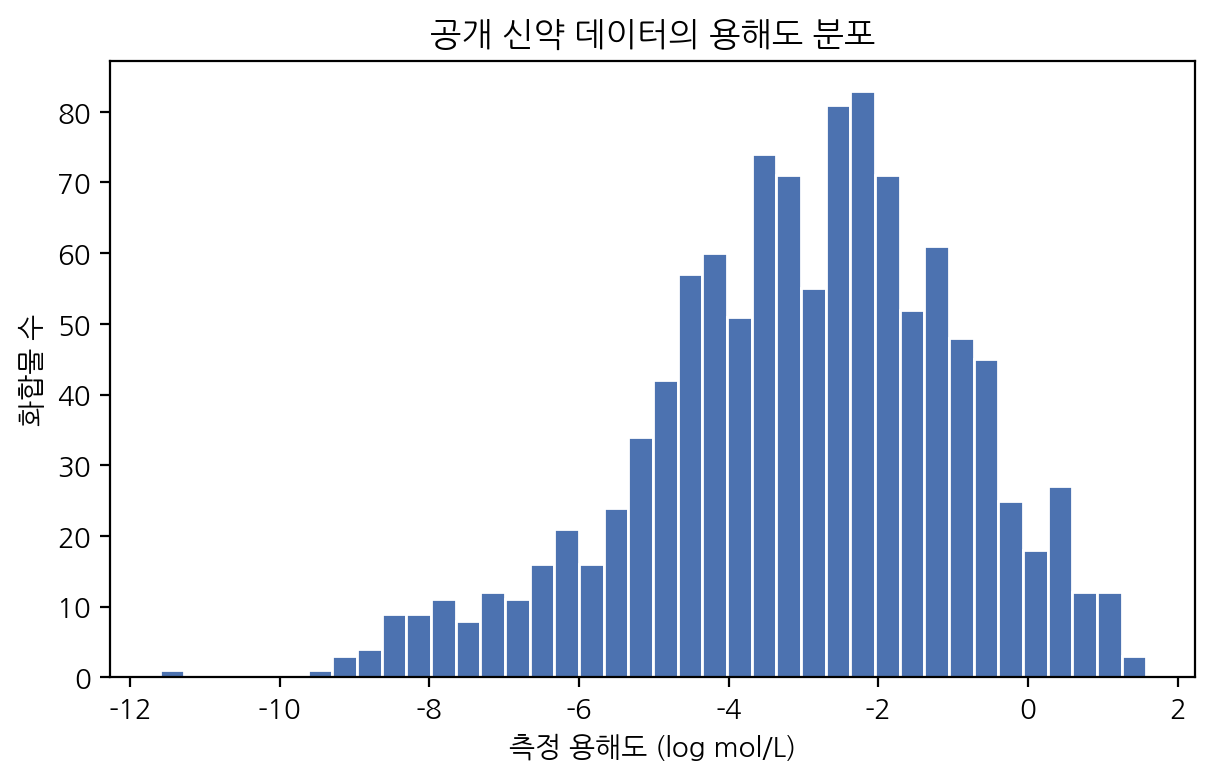

In [ ]:
# 용해도 값의 분포를 히스토그램으로 (현장에서 '데이터를 눈으로 보는' 첫 단계)

# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

col = "measured log solubility in mols per litre"
plt.figure(figsize=(7,4))
plt.hist(df[col], bins=40, color="#4C72B0", edgecolor="white")
plt.xlabel("측정 용해도 (log mol/L)"); plt.ylabel("화합물 수")
plt.title("공개 신약 데이터의 용해도 분포")
plt.show()

## 4. ⭐ 핵심 워크플로우: LLM에게 코드를 시키기
파이썬 문법을 몰라도 됩니다. **원하는 것을 정확히 말로 설명**하면 Gemini/Claude 가 코드를 써 줍니다.

### 좋은 프롬프트의 4가지 요소
1. **역할/맥락**: "너는 파이썬 데이터 분석가야. 나는 파이썬 초보야."
2. **데이터 설명**: "df 라는 데이터프레임이 있고, 열은 smiles, 용해도 값이 있어."
3. **하고 싶은 것(구체적으로)**: "용해도가 가장 낮은 화합물 10개를 표로 보여줘."
4. **형식/제약**: "설명은 한글 주석으로, matplotlib 로 그래프도 그려줘."

### 예시 프롬프트 (그대로 복사해서 Gemini 에 붙여보세요)
```
너는 친절한 파이썬 데이터 분석 튜터야. 나는 파이썬을 처음 배우는 제약 연구원이야.
pandas 데이터프레임 df 가 있고, 열은 'Compound ID', 'smiles',
'measured log solubility in mols per litre' 야.
용해도가 가장 낮은(=물에 안 녹는) 화합물 상위 10개를 골라서
Compound ID 와 용해도만 표로 출력하는 코드를 써줘. 코드에는 한글 주석을 달아줘.
```
아래는 그렇게 받은 코드의 예시입니다 👇


In [ ]:
# 👇 LLM 이 만들어줄 법한 코드 (직접 실행해보며 결과를 검증합니다)
col = "measured log solubility in mols per litre"

# 용해도가 낮은 순(오름차순)으로 정렬 후 상위 10개
worst10 = df.sort_values(col, ascending=True).head(10)

# 보고 싶은 열만 선택해서 출력
worst10[["Compound ID", col]]

,Compound ID,measured log solubility in mols per litre
603,"2,2',3,3',4,4',5,5',6,6'-PCB",-11.600
718,Coronene,-9.332
297,"2,2',3,3',4,4',5,5'-PCB",-9.160
60,"2,2',3,3',5,5',6,6'-PCB",-9.150
676,Benzo[ghi]perylene,-9.018
879,"2,2',3,4,5,5',6-PCB",-8.940
220,Perylene,-8.804
871,"2,2',4,4',6,6'-PCB",-8.710
637,Benzo(a)pyrene,-8.699
181,Etofenprox,-8.600


### 🔁 실습: 여러분 차례입니다
아래 빈 셀에서, LLM 에게 다음을 요청해 코드를 받아 붙여넣고 실행해 보세요.
- "용해도가 **가장 높은**(물에 잘 녹는) 화합물 5개를 보여줘"
- "smiles 글자 길이를 새로운 열 `len` 으로 추가하고, 분자 크기와 용해도의 관계를 산점도로 그려줘"

> **검증 습관**: LLM 코드는 항상 실행해서 결과가 말이 되는지 확인하세요.
> 에러가 나면 에러 메시지를 그대로 LLM 에 붙여넣고 "이 에러 고쳐줘" 라고 하면 됩니다.


In [ ]:
# ✏️ 여기에 LLM 에게 받은 코드를 붙여넣고 실행하세요


## 정리
- Colab = 설치 없이 브라우저에서 파이썬 실행 (무료 GPU)
- pandas 로 CSV 를 열고 `.head()`, `.describe()`, 그래프로 데이터를 **눈으로** 확인
- **핵심 역량**: 문제를 말로 정확히 설명 → LLM 코드 생성 → Colab 실행/검증 → 에러는 다시 LLM 에게
- 다음 예제부터는 이 데이터로 **실제 예측 모델(회귀)** 을 만들어 봅니다.
